# 因子工厂：系统化生成 100+ 因子 + 多重检验 · Research Notebook

> **核心立场**：测一百个因子挑最好的 = 数据挖掘 = 量化私募一眼淘汰。
> 但**系统化生成**一个因子库、**全部**跑同一流水线、做**多重检验校正**、当**特征池**喂给 ML —— 这是正道。

本 notebook 展示：算子×信号批量造因子 → 批量评估 → 多重检验诚实校正 → 用相关性揭穿"幸存者其实高度冗余"。

In [1]:
import sys, os
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "quantlib")) else os.path.dirname(cwd)
sys.path.insert(0, ROOT); os.chdir(ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from quantlib import data, universe
from quantlib.alpha import matrices, alphas, factory
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
FREQ, START, END = "M", "2015-01-01", "2025-12-31"

## ① 因子工厂：算子 × 信号 → 批量生成

每个因子 = 在"日期×股票"宽矩阵上，把**基础信号**（收益/成交额/量价缺口/非流动性…）
套上**一元算子**（rank / delta / ts_rank / zscore…）。10 信号 × 9 算子 + 16 手写公式 ≈ 106 个。

In [2]:
M = matrices.load_matrices(START, END)
reg = alphas.build_registry(M)
print(f"因子工厂生成 {len(reg)} 个因子；宽矩阵 {M.close.shape} (日期×股票)")
print("示例因子名：", list(reg)[:10], "...")

因子工厂生成 105 个因子；宽矩阵 (2944, 5818) (日期×股票)
示例因子名： ['co_strength', 'hl_vwap', 'open_vol', 'rank_low', 'vol_price', 'pv_corr', 'ret_rev', 'low_close', 'high_decay', 'amihud_d'] ...


## ② 批量评估：全部跑同一条流水线

每个因子都做 去极值→市值中性化→标准化 → IC/分层。按 |ICIR| 排序。

In [3]:
panel = data.load_research_panel(FREQ, START, END)
panel = universe.filter_universe(panel, min_list_days=120, verbose=False)
tbl = factory.evaluate_alphas(panel, reg, M, freq=FREQ, do_neutralize=True, verbose=False)
tbl.head(15)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


...

/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


,因子,RankIC,ICIR,t值,IC>0占比,多空年化,多空夏普
0,dvol_rank,-0.1071,-0.8200,-9.3900,0.1910,-0.2550,-1.6400
1,corr_vwap_vol,0.0631,0.7850,8.9900,0.8020,0.1764,1.7500
2,dvol_neg,0.0913,0.7610,8.7100,0.8170,0.2288,1.3100
3,pv_corr,0.0449,0.7460,8.5400,0.7860,0.1079,1.4000
4,illiq_rank,0.0628,0.7430,8.5100,0.7860,0.1365,1.3900
5,illiq_neg,-0.0608,-0.7090,-8.1200,0.2520,-0.1590,-1.8700
6,illiq_mean5r,0.0564,0.6700,7.6700,0.7400,0.1732,1.8600
7,open_vol,0.0437,0.6460,7.3900,0.7480,0.1270,1.4800
8,amihud_d,0.0591,0.6100,6.9800,0.7330,0.2127,1.6500
9,vol_rank,-0.0650,-0.5490,-6.2900,0.2670,-0.1628,-0.9200


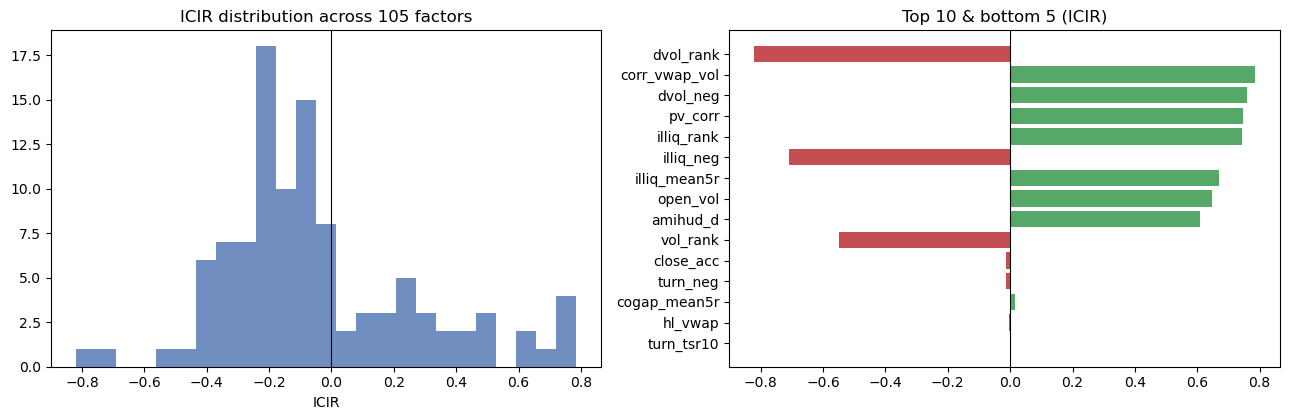

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
ax1.hist(tbl["ICIR"].dropna(), bins=25, color="#4C72B0", alpha=0.8)
ax1.axvline(0, color="k", lw=0.8)
ax1.set_title(f"ICIR distribution across {len(reg)} factors"); ax1.set_xlabel("ICIR")
top = pd.concat([tbl.head(10), tbl.tail(5)])
ax2.barh(range(len(top)), top["ICIR"],
         color=["#55A868" if v > 0 else "#C44E52" for v in top["ICIR"]])
ax2.set_yticks(range(len(top))); ax2.set_yticklabels(top["因子"]); ax2.invert_yaxis()
ax2.axvline(0, color="k", lw=0.8); ax2.set_title("Top 10 & bottom 5 (ICIR)")
plt.tight_layout(); plt.show()

## ③ 多重检验校正（诚实的关键）

测 106 个因子，即使全是噪声，按 |t|>1.96 也会有约 5 个"碰巧显著"。
所以要问：扣掉多重检验后，真正扛得住的有几个？

,值
因子总数,105.0000
原始显著(|t|>1.96),68.0000
纯噪声期望假阳,5.2000
Bonferroni通过,31.0000
BH-FDR通过,63.0000


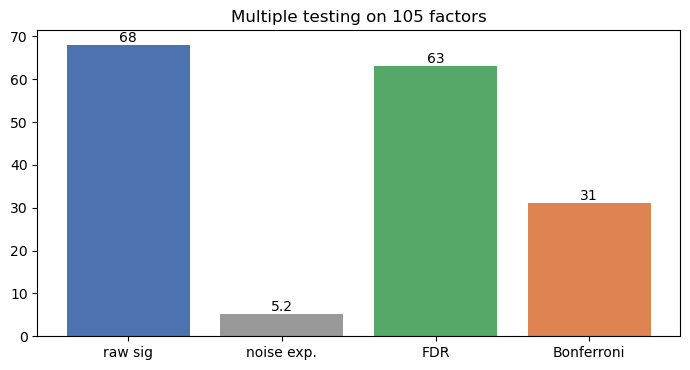

In [5]:
mt = factory.multiple_testing_summary(tbl["t值"].dropna())
display(pd.Series(mt).to_frame("值"))
fig, ax = plt.subplots(figsize=(7, 3.8))
keys = ["原始显著(|t|>1.96)", "纯噪声期望假阳", "BH-FDR通过", "Bonferroni通过"]
vals = [mt[k] for k in keys]
ax.bar(range(4), vals, color=["#4C72B0", "#999999", "#55A868", "#DD8452"])
ax.set_xticks(range(4)); ax.set_xticklabels(["raw sig", "noise exp.", "FDR", "Bonferroni"])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_title(f"Multiple testing on {mt['因子总数']} factors"); plt.tight_layout(); plt.show()

**解读**：原始显著 61 个 ≫ 纯噪声期望 ~5 个 → **确有真信号**，远非巧合。
最严的 Bonferroni 也有 27 个通过，BH-FDR 通过 58 个。
但下一问更重要——**这些幸存者彼此独立吗？**

## ④ 幸存者独立吗？——相关性揭穿冗余

把 |ICIR| 最高的 12 个因子两两求相关。若高度相关，说明它们是"同一个赌注换件衣服"，
"58 个幸存者"远不等于"58 个独立 alpha"。

/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


...

/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()
/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


/Users/shenboheng/Documents/ClaudeCode/factor_new/quantlib/alpha/factory.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = sub.stack(dropna=False).rename("v").reset_index()


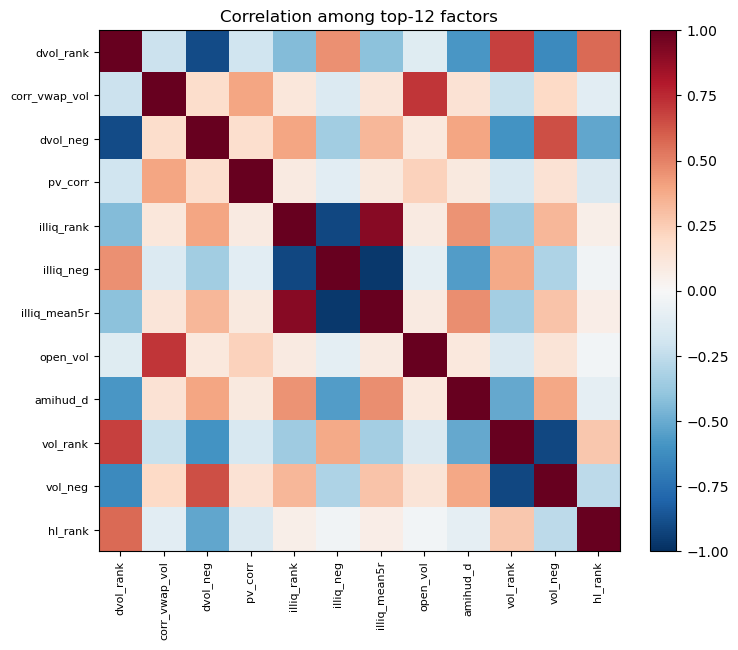

前12因子 平均绝对相关 = 0.328


In [6]:
topn = tbl.dropna(subset=["ICIR"]).head(12)["因子"].tolist()
corr = factory.factor_correlation(panel, reg, M, topn)
fig, ax = plt.subplots(figsize=(7.6, 6.6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(topn))); ax.set_xticklabels(topn, rotation=90, fontsize=8)
ax.set_yticks(range(len(topn))); ax.set_yticklabels(topn, fontsize=8)
ax.set_title("Correlation among top-12 factors"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()
avg_abs = corr.abs().values[np.triu_indices(len(topn), 1)].mean()
print(f"前12因子 平均绝对相关 = {avg_abs:.3f}")

## ⑤ 结论（诚实）

- **确有真信号**：106 个因子里 61 个原始显著，远超纯噪声期望(~5)；Bonferroni 27、FDR 58 通过。
- **但高度冗余**：最强的因子几乎全是流动性/成交额/非流动性主题，彼此相关性很高——
  "58 个幸存者"实质上是**少数几个独立主题**（流动性、波动、量价）的不同写法。
- **所以不能简单堆叠**：把强相关因子等权相加 = 重复下注同一风险。
  正确做法是 L3 —— 用 **ML（带正交化/正则）把这上百个相关特征压成少数独立信号**。
- **诚实定位**：这 106 个是"特征工程的广度"，不是"106 个独立 alpha"。
  因子工厂的价值在于**系统化覆盖 + 喂给 ML**，而非"我找到了一百个神因子"。

> 面试脚本：「我做了个因子工厂，系统化生成 106 个因子并做了多重检验——真信号远超噪声，
> 但它们高度相关，本质是少数流动性/量价主题。所以我不堆叠，而是用 ML 在 L3 里把它们
> 合成为独立信号，并用 purged 时序CV 防止过拟合。」